# Ćwiczenie 3 i 4: modele kliniczne + sieć neuronowa (zbiór `cukrzyca`)

W tym notatniku robimy dokładnie to, o co chodzi w ćwiczeniu laboratoryjnym:

1. **Modele klasyfikacji i regresji** na danych klinicznych.
2. **Prosta sieć neuronowa CNN** do analizy danych w formie obrazów.

Wszystko jest opisane prostym językiem: **co robimy, po co i jaki to ma wpływ na wynik**.

## 0. Biblioteki i importy

Dlaczego to ważne?
- `pandas`, `numpy`: czytanie i obrabianie danych.
- `scikit-learn`: klasyczne modele ML.
- `tensorflow/keras`: CNN.
- `matplotlib`, `seaborn`: wykresy, żeby zobaczyć jakość modeli.

In [1]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    mean_squared_error, r2_score
)

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    TF_AVAILABLE = True
except Exception as e:
    TF_AVAILABLE = False
    print('TensorFlow niedostępny:', e)

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (9, 5)
sns.set_theme(style='whitegrid')

print('Importy gotowe.')

Importy gotowe.


## 1. Wczytanie danych ze zbioru `cukrzyca`

Każdy plik `data-XX` to jeden pacjent i jego dziennik zdarzeń (czas, kod zdarzenia, wartość).

Najpierw łączymy wszystko w jedną tabelę, bo modele uczą się na jednej wspólnej macierzy cech.

In [2]:
DATA_DIR = 'cukrzyca'
file_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'data-*')))
print(f'Liczba plików pacjentów: {len(file_paths)}')

all_rows = []
for path in file_paths:
    patient_id = os.path.basename(path)
    tmp = pd.read_csv(path, sep='\t', header=None, names=['date', 'time', 'code', 'value'])
    tmp['patient_id'] = patient_id
    all_rows.append(tmp)

raw = pd.concat(all_rows, ignore_index=True)
raw['datetime'] = pd.to_datetime(raw['date'] + ' ' + raw['time'], errors='coerce')
raw['date_only'] = raw['datetime'].dt.date
raw['hour'] = raw['datetime'].dt.hour + raw['datetime'].dt.minute / 60
raw['code'] = pd.to_numeric(raw['code'], errors='coerce')
raw['value'] = pd.to_numeric(raw['value'], errors='coerce')

display(raw.head(10))
print('Rozmiar tabeli:', raw.shape)

Liczba plików pacjentów: 70


,date,time,code,value,patient_id,datetime,date_only,hour
0,04-21-1991,9:09,58,100.0,data-01,1991-04-21 09:09:00,1991-04-21,9.150000
1,04-21-1991,9:09,33,9.0,data-01,1991-04-21 09:09:00,1991-04-21,9.150000
2,04-21-1991,9:09,34,13.0,data-01,1991-04-21 09:09:00,1991-04-21,9.150000
3,04-21-1991,17:08,62,119.0,data-01,1991-04-21 17:08:00,1991-04-21,17.133333
4,04-21-1991,17:08,33,7.0,data-01,1991-04-21 17:08:00,1991-04-21,17.133333
5,04-21-1991,22:51,48,123.0,data-01,1991-04-21 22:51:00,1991-04-21,22.850000
6,04-22-1991,7:35,58,216.0,data-01,1991-04-22 07:35:00,1991-04-22,7.583333
7,04-22-1991,7:35,33,10.0,data-01,1991-04-22 07:35:00,1991-04-22,7.583333
8,04-22-1991,7:35,34,13.0,data-01,1991-04-22 07:35:00,1991-04-22,7.583333
9,04-22-1991,13:40,33,2.0,data-01,1991-04-22 13:40:00,1991-04-22,13.666667


Rozmiar tabeli: (29330, 8)


## 2. Przygotowanie cech dziennych (feature engineering)

Co robimy i po co:
- Wybieramy kody glukozy i insuliny.
- Budujemy **cechy dzienne** (np. średnia glukoza, max glukoza, dawka insuliny).

Wpływ: dobre cechy = model łatwiej widzi zależności i lepiej przewiduje.

In [3]:
# Przybliżone grupy kodów używane w klasycznym zbiorze diabetes
GLUCOSE_CODES = {48, 57, 58, 59, 60, 61, 62, 63, 64}
INSULIN_CODES = {33, 34, 35}
MEAL_CODES = {66, 67, 68}
EXERCISE_CODES = {69, 70, 71}

g = raw[raw['code'].isin(GLUCOSE_CODES)].copy()
ins = raw[raw['code'].isin(INSULIN_CODES)].copy()
meal = raw[raw['code'].isin(MEAL_CODES)].copy()
exercise = raw[raw['code'].isin(EXERCISE_CODES)].copy()

daily_glucose = g.groupby(['patient_id', 'date_only']).agg(
    mean_glucose=('value', 'mean'),
    std_glucose=('value', 'std'),
    min_glucose=('value', 'min'),
    max_glucose=('value', 'max'),
    glucose_measurements=('value', 'count'),
    morning_glucose=('value', lambda s: s[g.loc[s.index, 'hour'] < 12].mean()),
    evening_glucose=('value', lambda s: s[g.loc[s.index, 'hour'] >= 18].mean())
).reset_index()

daily_insulin = ins.groupby(['patient_id', 'date_only']).agg(
    insulin_total=('value', 'sum'),
    insulin_events=('value', 'count')
).reset_index()

daily_meal = meal.groupby(['patient_id', 'date_only']).agg(
    meal_events=('value', 'count')
).reset_index()

daily_exercise = exercise.groupby(['patient_id', 'date_only']).agg(
    exercise_events=('value', 'count')
).reset_index()

daily = daily_glucose.merge(daily_insulin, on=['patient_id', 'date_only'], how='left')
daily = daily.merge(daily_meal, on=['patient_id', 'date_only'], how='left')
daily = daily.merge(daily_exercise, on=['patient_id', 'date_only'], how='left')

for c in ['insulin_total', 'insulin_events', 'meal_events', 'exercise_events', 'std_glucose', 'morning_glucose', 'evening_glucose']:
    daily[c] = daily[c].fillna(0)

daily['date_only'] = pd.to_datetime(daily['date_only'])
daily['day_of_week'] = daily['date_only'].dt.day_name()
daily = daily.sort_values(['patient_id', 'date_only']).reset_index(drop=True)

display(daily.head(10))
print('Liczba rekordów dziennych:', len(daily))

,patient_id,date_only,mean_glucose,std_glucose,min_glucose,max_glucose,glucose_measurements,morning_glucose,evening_glucose,insulin_total,insulin_events,meal_events,exercise_events,day_of_week
0,data-01,1991-04-21,114.0,12.288206,100.0,123.0,3,100.0,123.0,29.0,3.0,0.0,0.0,Sunday
1,data-01,1991-04-22,213.5,3.535534,211.0,216.0,2,216.0,0.0,32.0,4.0,0.0,0.0,Monday
2,data-01,1991-04-23,193.0,90.509668,129.0,257.0,2,257.0,0.0,31.0,3.0,0.0,0.0,Tuesday
3,data-01,1991-04-24,236.0,105.531986,129.0,340.0,3,239.0,340.0,33.0,4.0,0.0,0.0,Wednesday
4,data-01,1991-04-25,187.0,111.718396,67.0,288.0,3,67.0,288.0,36.0,5.0,0.0,0.0,Thursday
5,data-01,1991-04-26,152.5,106.773124,77.0,228.0,2,77.0,0.0,35.0,4.0,0.0,0.0,Friday
6,data-01,1991-04-27,257.5,2.121320,256.0,259.0,2,259.0,0.0,32.0,3.0,0.0,0.0,Saturday
7,data-01,1991-04-28,135.0,56.665686,96.0,200.0,3,109.0,200.0,31.0,3.0,0.0,0.0,Sunday
8,data-01,1991-04-29,166.0,79.065374,81.0,263.0,4,128.0,81.0,36.0,4.0,0.0,0.0,Monday
9,data-01,1991-04-30,139.0,50.139805,88.0,185.0,4,179.0,104.0,35.0,4.0,0.0,0.0,Tuesday


Liczba rekordów dziennych: 3859


## 3. Definicja celów predykcji

Żeby mieć sens medyczny, przewidujemy **co stanie się jutro**:
- Klasyfikacja: czy jutro pojawi się hiperglikemia (`next_day_hyper`, próg 180).
- Regresja: jaka będzie średnia glukoza jutro (`next_day_mean_glucose`).

Wpływ: unikamy przecieku informacji i model ma bardziej praktyczne zastosowanie.

In [4]:
daily['next_day_mean_glucose'] = daily.groupby('patient_id')['mean_glucose'].shift(-1)
daily['next_day_max_glucose'] = daily.groupby('patient_id')['max_glucose'].shift(-1)
daily['next_day_hyper'] = (daily['next_day_max_glucose'] >= 180).astype(float)

model_df = daily.dropna(subset=['next_day_mean_glucose', 'next_day_hyper']).copy()
model_df['next_day_hyper'] = model_df['next_day_hyper'].astype(int)

print('Dane do modelowania:', model_df.shape)
print('Procent klasy 1 (hiperglikemia jutro):', round(model_df['next_day_hyper'].mean() * 100, 2), '%')

Dane do modelowania: (3789, 17)
Procent klasy 1 (hiperglikemia jutro): 68.7 %


## 4. Klasyfikacja (LogisticRegression + DecisionTreeClassifier)

Tu realizujemy temat 1 z instrukcji: klasyfikacja na danych klinicznych.

Oceniamy: accuracy, precision, recall, F1 i ROC AUC.

In [5]:
feature_cols = [
    'mean_glucose', 'std_glucose', 'min_glucose', 'max_glucose',
    'glucose_measurements', 'morning_glucose', 'evening_glucose',
    'insulin_total', 'insulin_events', 'meal_events', 'exercise_events',
    'day_of_week'
]

Xc = model_df[feature_cols].copy()
yc = model_df['next_day_hyper'].copy()

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.25, random_state=42, stratify=yc
)

num_cols = Xc_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = Xc_train.select_dtypes(include=['object', 'category']).columns.tolist()

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

prep = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

clf_log = Pipeline([
    ('prep', prep),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

clf_tree = Pipeline([
    ('prep', prep),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

models_cls = {
    'LogisticRegression': clf_log,
    'DecisionTreeClassifier': clf_tree
}

results_cls = []
for name, mdl in models_cls.items():
    mdl.fit(Xc_train, yc_train)
    pred = mdl.predict(Xc_test)
    if hasattr(mdl, 'predict_proba'):
        proba = mdl.predict_proba(Xc_test)[:, 1]
    else:
        proba = pred

    results_cls.append({
        'model': name,
        'accuracy': accuracy_score(yc_test, pred),
        'precision': precision_score(yc_test, pred, zero_division=0),
        'recall': recall_score(yc_test, pred, zero_division=0),
        'f1': f1_score(yc_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(yc_test, proba)
    })

results_cls_df = pd.DataFrame(results_cls).sort_values('f1', ascending=False)
display(results_cls_df)

best_cls_name = results_cls_df.iloc[0]['model']
best_cls = models_cls[best_cls_name]
print('Najlepszy model klasyfikacji:', best_cls_name)

,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.742616,0.763260,0.906298,0.828652,0.734741
1,DecisionTreeClassifier,0.746835,0.776581,0.886329,0.827834,0.728113


Najlepszy model klasyfikacji: LogisticRegression


Raport klasyfikacji:
              precision    recall  f1-score   support

           0      0.651     0.384     0.483       297
           1      0.763     0.906     0.829       651

    accuracy                          0.743       948
   macro avg      0.707     0.645     0.656       948
weighted avg      0.728     0.743     0.720       948



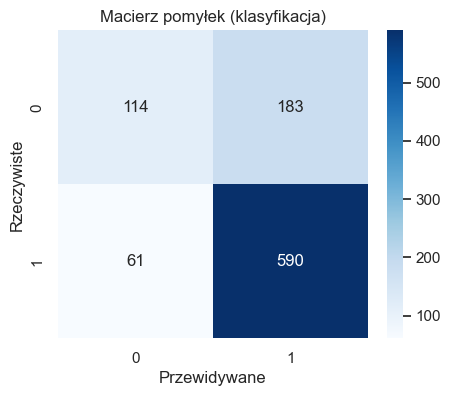

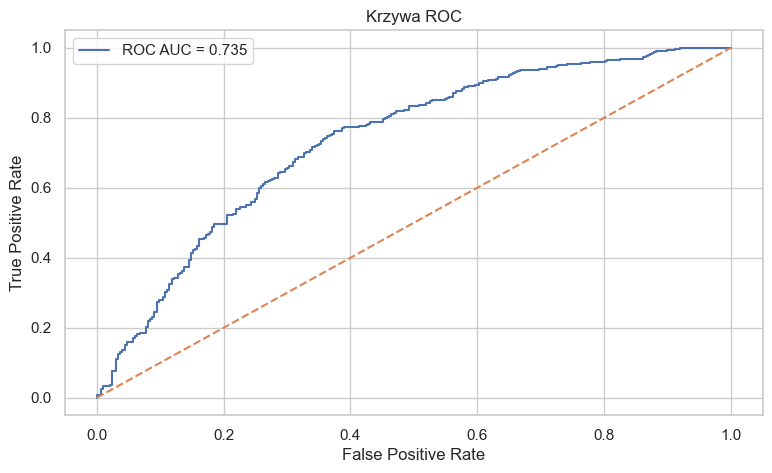

In [6]:
# Wizualizacja jakości klasyfikacji
pred_best = best_cls.predict(Xc_test)
proba_best = best_cls.predict_proba(Xc_test)[:, 1]

print('Raport klasyfikacji:')
print(classification_report(yc_test, pred_best, digits=3))

cm = confusion_matrix(yc_test, pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Macierz pomyłek (klasyfikacja)')
plt.xlabel('Przewidywane')
plt.ylabel('Rzeczywiste')
plt.show()

fpr, tpr, _ = roc_curve(yc_test, proba_best)
auc = roc_auc_score(yc_test, proba_best)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--')
plt.title('Krzywa ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 5. Regresja (LinearRegression)

Teraz przewidujemy wartość liczbową: **średnią glukozę jutro**.

Oceniamy: RMSE i R2.

In [7]:
Xr = model_df[feature_cols].copy()
yr = model_df['next_day_mean_glucose'].copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.25, random_state=42
)

num_cols_r = Xr_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_r = Xr_train.select_dtypes(include=['object', 'category']).columns.tolist()

prep_r = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols_r),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols_r)
])

reg = Pipeline([
    ('prep', prep_r),
    ('model', LinearRegression())
])

reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

print(f'RMSE: {rmse:.2f}')
print(f'R2:   {r2:.3f}')

RMSE: 50.83
R2:   0.117


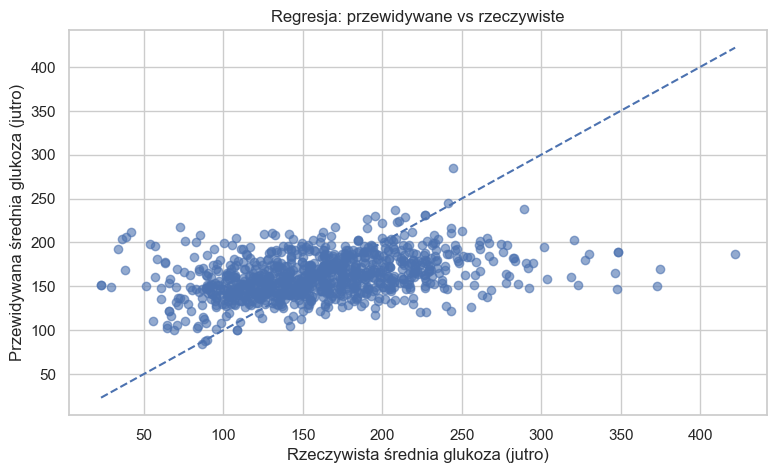

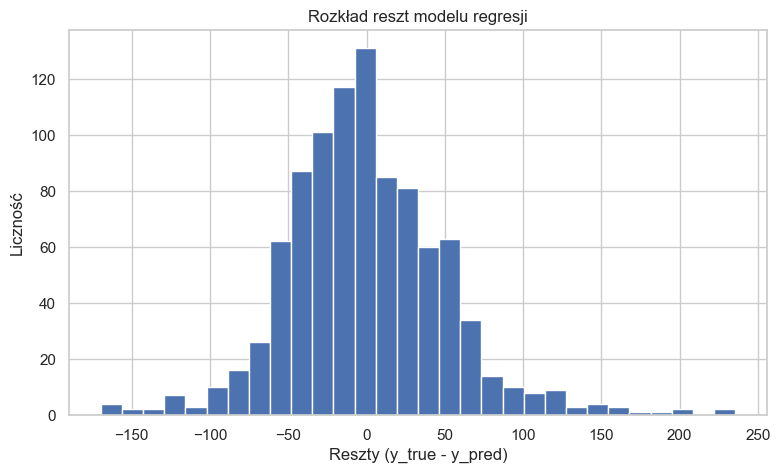

In [8]:
# Wykres: przewidywane vs rzeczywiste
plt.figure()
plt.scatter(yr_test, yr_pred, alpha=0.6)
mn = min(yr_test.min(), yr_pred.min())
mx = max(yr_test.max(), yr_pred.max())
plt.plot([mn, mx], [mn, mx], '--')
plt.xlabel('Rzeczywista średnia glukoza (jutro)')
plt.ylabel('Przewidywana średnia glukoza (jutro)')
plt.title('Regresja: przewidywane vs rzeczywiste')
plt.show()

# Wykres rozkładu błędów
residuals = yr_test - yr_pred
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel('Reszty (y_true - y_pred)')
plt.ylabel('Liczność')
plt.title('Rozkład reszt modelu regresji')
plt.show()

## 6. CNN: tworzenie obrazów z przebiegu glukozy (wersja dydaktyczna)

W zbiorze `cukrzyca` nie ma gotowych plików JPG/PNG, więc robimy prosty trik dydaktyczny:
- z dobowego przebiegu glukozy tworzymy mały obraz 24x24,
- etykieta: czy tego dnia wystąpiła hiperglikemia (max glukoza >= 180).

To pokazuje pełny pipeline CNN (generator, trening, ocena), który potem można przenieść na prawdziwe obrazy medyczne.

In [9]:
def make_daily_image(day_df, size=24):
    day_df = day_df.sort_values('hour')
    x = day_df['hour'].values
    y = day_df['value'].values
    if len(x) < 2:
        return None

    grid = np.linspace(0, 23, size)
    profile = np.interp(grid, x, y)
    profile = np.clip(profile / 400.0, 0, 1)

    img = (np.tile(profile, (size, 1)) + np.tile(profile.reshape(-1, 1), (1, size))) / 2
    return img.astype('float32')

img_rows = []
for (pid, d), grp in g.groupby(['patient_id', 'date_only']):
    if len(grp) < 3:
        continue
    img = make_daily_image(grp, size=24)
    if img is None:
        continue
    label = int(grp['value'].max() >= 180)
    img_rows.append((pid, d, img, label))

img_df = pd.DataFrame(img_rows, columns=['patient_id', 'date_only', 'image', 'label'])
print('Liczba próbek obrazowych:', len(img_df))
print('Udział klasy 1:', round(img_df['label'].mean() * 100, 2), '%')

X_img = np.stack(img_df['image'].values)
y_img = img_df['label'].values
X_img = np.expand_dims(X_img, axis=-1)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_img, y_img, test_size=0.25, random_state=42, stratify=y_img
)

print('X_train_i:', X_train_i.shape, 'X_test_i:', X_test_i.shape)

Liczba próbek obrazowych: 3312
Udział klasy 1: 69.96 %
X_train_i: (2484, 24, 24, 1) X_test_i: (828, 24, 24, 1)


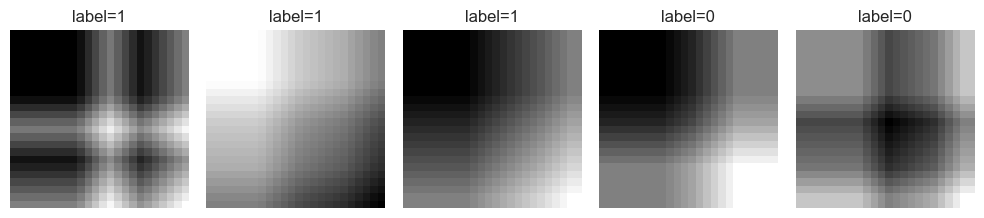

In [10]:
# Podgląd kilku obrazów
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train_i[i, :, :, 0], cmap='gray')
    plt.title(f'label={y_train_i[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [11]:
# ImageDataGenerator zgodnie z instrukcją ćwiczenia
if TF_AVAILABLE:
    train_gen = ImageDataGenerator(
        rotation_range=8,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.05
    )

    test_gen = ImageDataGenerator()

    batch_size = 32
    train_flow = train_gen.flow(X_train_i, y_train_i, batch_size=batch_size, shuffle=True)
    test_flow = test_gen.flow(X_test_i, y_test_i, batch_size=batch_size, shuffle=False)
else:
    train_flow = None
    test_flow = None
    print('Pomijam trening CNN, bo TensorFlow nie jest dostępny.')

In [12]:
# Prosta sieć CNN: Conv + Pool + Flatten + Dense
if TF_AVAILABLE:
    cnn = keras.Sequential([
        layers.Input(shape=X_train_i.shape[1:]),
        layers.Conv2D(16, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    cnn.summary()
else:
    cnn = None

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,697 (147.25 KB)

 Trainable params: 37,697 (147.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
if TF_AVAILABLE and cnn is not None:
    history = cnn.fit(
        train_flow,
        validation_data=test_flow,
        epochs=12,
        verbose=1
    )
else:
    history = None
    print('Trening CNN pominięty (brak TensorFlow).')

Epoch 1/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6531 - loss: 0.6198 - val_accuracy: 0.6993 - val_loss: 0.6127
Epoch 2/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7207 - loss: 0.5923 - val_accuracy: 0.6993 - val_loss: 0.6123
Epoch 3/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6952 - loss: 0.6153 - val_accuracy: 0.6993 - val_loss: 0.6115
Epoch 4/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7097 - loss: 0.6030 - val_accuracy: 0.6993 - val_loss: 0.6117
Epoch 5/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6850 - loss: 0.6248 - val_accuracy: 0.6993 - val_loss: 0.6115
Epoch 6/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6993 - loss: 0.6126 - val_accuracy: 0.6993 - val_loss: 0.6115
Epoch 7/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7049 - loss: 0.6078 - val_accuracy: 0.6993 - val_loss: 0.6123
Epoch 8/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7027 - loss: 0.6100 - val_accuracy: 0.6993 - v

Test loss: 0.6122
Test accuracy: 0.6993


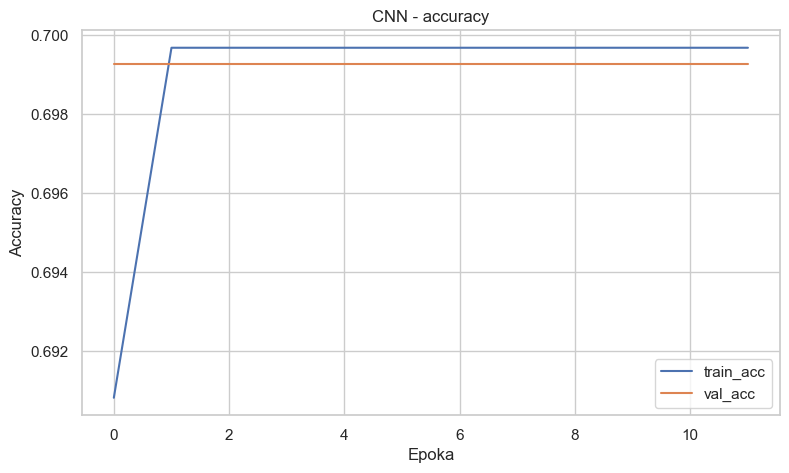

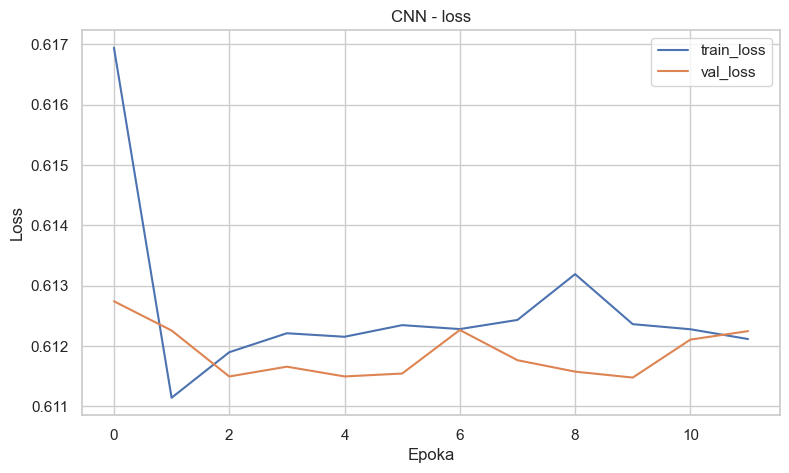

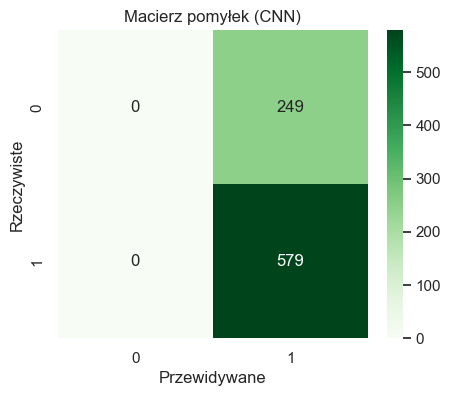

Model zapisany jako cnn_cukrzyca.keras


In [14]:
if TF_AVAILABLE and cnn is not None and history is not None:
    loss, acc = cnn.evaluate(test_flow, verbose=0)
    print(f'Test loss: {loss:.4f}')
    print(f'Test accuracy: {acc:.4f}')

    # Krzywe uczenia
    plt.figure()
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.title('CNN - accuracy')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.title('CNN - loss')
    plt.legend()
    plt.show()

    # Macierz pomyłek
    y_prob = cnn.predict(X_test_i, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    cm_cnn = confusion_matrix(y_test_i, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens')
    plt.title('Macierz pomyłek (CNN)')
    plt.xlabel('Przewidywane')
    plt.ylabel('Rzeczywiste')
    plt.show()

    # Zapis modelu
    cnn.save('cnn_cukrzyca.keras')
    print('Model zapisany jako cnn_cukrzyca.keras')
else:
    print('Ocena i zapis CNN pominięte (brak TensorFlow).')

## 7. Bardzo krótkie wnioski

1. Dane trzeba dobrze przygotować (cechy, brakujące dane, podział train/test), bo to mocno wpływa na wynik.
2. Modele klasyczne (logistyczna, drzewo, liniowa) dają szybki i czytelny punkt odniesienia.
3. CNN potrafi uczyć się wzorców z danych obrazowych, ale wymaga większej liczby próbek i strojenia.
4. W medycynie sama dokładność nie wystarcza: ważne są też recall/precision i sens kliniczny modelu.